# VMGP: Variational Auto-Encoder Multi-task Genomic Prediction
## Training & Risultati

Questo notebook utilizza il modulo `vae/` per training e analisi.

### Struttura del Modulo:
- `vae/network.py` - Architettura VMGP
- `vae/lightning_module.py` - Logic training (PyTorch Lightning)
- `vae/data_module.py` - Caricamento e preprocessing dati PLINK
- `vae/utils.py` - Funzioni di utilità (balancing, metriche)
- `vae/experiment.py` - Runner esperimenti con K-Fold CV
- `vae/analysis.py` - Analisi post-training

---

## 1. Setup e Imports

In [3]:
import os
import sys
import torch
import pandas as pd
import pytorch_lightning as pl

# Aggiungi la directory parent al path per importare il modulo vae
sys.path.insert(0, os.path.dirname(os.getcwd()))

# Imposta seed per riproducibilità
pl.seed_everything(42)
# Import modulo VAE
from vae import (
    VMGP_Network,
    VMGP_LightningSystem,
    GenomicDataModule,
    run_experiment,
    CLASSIFIER_CONFIGS,
    analyze_model_performance
)

print("✅ Moduli caricati correttamente!")
print(f"🔧 CUDA disponibile: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

Seed set to 42


✅ Moduli caricati correttamente!
🔧 CUDA disponibile: True
   GPU: NVIDIA GeForce RTX 5070 Ti


## 2. Configurazione

In [4]:
# ⚠️ MODIFICA QUESTI PATH CON IL TUO DATASET ⚠️
BED_PATH = "../data/ADAPTmap_genotypeTOP_20160222_full.bed"
METADATA_PATH = "classificazione-capre.csv"

# Coarse Grained Mapping
COARSE_MAPPING = {
    'LATTE': ['ALP', 'ARG', 'ASP', 'BIO', 'CRS', 'GGT', 'KLS', 'LNR', 'MLG', 'MLS', 'MLT', 'MUG', 'NIC', 'ORO', 'PTV', 'RME', 'SAA', 'SAR', 'TOG', 'VSS', 'NRW'],
    'FIBRA': ['ANG', 'ANK', 'CAS'],
    'CARNE': ['BOE', 'RAN', 'TED', 'BRI', 'BEY', 'MOX', 'RAS', 'THA']
}

# Hyperparameters
config = {
    # DataModule
    'bed_path': BED_PATH,
    'metadata_path': METADATA_PATH,
    'batch_size': 256,
    'maf_thresh': 0.01,
    'geno_thresh': 0.1,
    'min_samples_per_class': 20,
    'ld_pruning': True,
    'ld_threshold': 0.2,
    'ld_window': 50,
    'val_split': 0.15,
    'test_split': 0.15,
    
    # Balancing
    'target_samples': 50,
    
    # Model (VMGP) - Loss weights
    'alpha': 0.5,
    'lr': 0.0001,
    
    # Pesi relativi dei classificatori
    'weight_breed': 1.0,
    'weight_continent': 1.0,
    'weight_caseina': 1.0,
    
    # Training
    'max_epochs': 100,
    'accelerator': 'gpu' if torch.cuda.is_available() else 'cpu',
    'devices': 1,
}

print("📋 CONFIGURAZIONE:")
for k, v in config.items():
    print(f"   {k}: {v}")

print("\n📊 CONFIGURAZIONI CLASSIFICATORI DISPONIBILI:")
for name, cfg in CLASSIFIER_CONFIGS.items():
    print(f"   {name}: {cfg['description']}")

📋 CONFIGURAZIONE:
   bed_path: ../data/ADAPTmap_genotypeTOP_20160222_full.bed
   metadata_path: classificazione-capre.csv
   batch_size: 256
   maf_thresh: 0.01
   geno_thresh: 0.1
   min_samples_per_class: 20
   ld_pruning: True
   ld_threshold: 0.2
   ld_window: 50
   val_split: 0.15
   test_split: 0.15
   target_samples: 50
   alpha: 0.5
   lr: 0.0001
   weight_breed: 1.0
   weight_continent: 1.0
   weight_caseina: 1.0
   max_epochs: 100
   accelerator: gpu
   devices: 1

📊 CONFIGURAZIONI CLASSIFICATORI DISPONIBILI:
   breed_only: Solo classificatore Breed (razza)
   continent_only: Solo classificatore Continent
   caseina_only: Solo classificatore Caseina
   attitudine_only: Solo classificatore Attitudine (LATTE/FIBRA/CARNE/ALTRO)
   breed_continent: Classificatori Breed + Continent
   breed_attitudine: Classificatori Breed + Attitudine (LATTE/FIBRA/CARNE/ALTRO)
   all_classifiers: Tutti i classificatori (Breed + Continent + Caseina)
   all_with_attitudine: Tutti i classificatori i

## 3. Training Esperimenti

Seleziona quali esperimenti eseguire decommentando le celle corrispondenti.

In [5]:
# Container per i risultati
all_results = []

### 3.1 Esperimenti Base (Solo Breed)

In [6]:
# 1. Original (Fine-Grained, Unbalanced) - Solo Breed
# res = run_experiment(
#     name="Original_Unbalanced_BreedOnly", 
#     config=config,
#     balanced=False, 
#     coarse_mapping=None, 
#     max_epochs=config['max_epochs'], 
#     classifier_config='breed_only'
# )

res1 = run_experiment(
    name="Original_Balanced_BreedOnly", 
    config=config,
    balanced=True, 
    coarse_mapping=None, 
    max_epochs=config['max_epochs'], 
    classifier_config='breed_only'
)
all_results.append(res1)


🧪 EXPERIMENT: Original_Balanced_BreedOnly
   Balanced: True
   Coarse Grained: False
   Classificatori: Breed=True, Continent=False, Caseina=False, Attitudine=False
   K-Fold CV: DISABILITATO (Single Split)


CARICAMENTO DATASET PLINK: ../data/ADAPTmap_genotypeTOP_20160222_full.bed
📋 Metadata caricato: 121 razze
📊 Shape iniziale: (4653, 53347) (4653 campioni, 53347 SNP)

🏷️  Estrazione label multiple...
   Continent: 3960/4653 campioni con label
   Caseina: 1191/4653 campioni con label

🔍 Filtro Razze Rare (min 20 campioni):
   Razze valide: 80/144
   Campioni rimossi: 612

🧬 QUALITY CONTROL PIPELINE
────────────────────────────────────────────────────────────
1️⃣  Filtro Missingness SNP...
    ✓ Rimossi 2049 SNP con missingness >10.0%
2️⃣  Imputazione valori mancanti (media)...
    ✓ Imputazione completata
3️⃣  Filtro MAF (Minor Allele Frequency)...
    ✓ Rimossi 4 SNP con MAF <0.01
4️⃣  LD Pruning (Window=50, r²>0.2)...
    Device: cuda
    ...50000/51294 SNP scansionati
    ✓ Rimos

KeyboardInterrupt: 

### 3.2 Esperimenti con Breed e Continent

In [ ]:
# 3. Original - Breed + Continent
res2 = run_experiment(
    name="Original_Balanced_Breed+Continent", 
    config=config,
    balanced=True, 
    coarse_mapping=None,
    max_epochs=config['max_epochs'], 
    classifier_config='breed_continent'
)
all_results.append(res2)


🧪 EXPERIMENT: Original_Balanced_Breed+Continent
   Balanced: True
   Coarse Grained: False
   Classificatori: Breed=True, Continent=True, Caseina=False, Attitudine=False
   K-Fold CV: DISABILITATO (Single Split)


CARICAMENTO DATASET PLINK: ../data/ADAPTmap_genotypeTOP_20160222_full.bed
📋 Metadata caricato: 121 razze
📊 Shape iniziale: (4653, 53347) (4653 campioni, 53347 SNP)

🏷️  Estrazione label multiple...
   Continent: 3960/4653 campioni con label
   Caseina: 1191/4653 campioni con label
   Continenti: ['Africa', 'Asia', 'Europe']

🔍 Filtro Razze Rare (min 20 campioni):
   Razze valide: 80/144
   Campioni rimossi: 612

🧬 QUALITY CONTROL PIPELINE
────────────────────────────────────────────────────────────
1️⃣  Filtro Missingness SNP...
    ✓ Rimossi 2049 SNP con missingness >10.0%
2️⃣  Imputazione valori mancanti (media)...
    ✓ Imputazione completata
3️⃣  Filtro MAF (Minor Allele Frequency)...
    ✓ Rimossi 4 SNP con MAF <0.01
4️⃣  LD Pruning (Window=50, r²>0.2)...
    Device: cu

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/lorenzo/Documenti/Uni/genomic-dataset-reduction/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /home/lorenzo/Documenti/Uni/genomic-dataset-reduction/vae/checkpoints_vae/Original_Balanced_Breed+Continent/fold_1 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


## 🔍 Diagnostica Overfitting

Verifica se l'accuracy è genuina o dovuta a overfitting.

In [ ]:
# === DIAGNOSTICA OVERFITTING ===
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Seleziona l'esperimento da analizzare
EXPERIMENT_NAME = "Original_Balanced_Breed+Continent"
checkpoint_path = f"checkpoints_vae/{EXPERIMENT_NAME}/best_model.ckpt"

# 1. CARICAMENTO MODELLO E DATI
if os.path.exists(checkpoint_path):
    print(f"📂 Caricamento: {checkpoint_path}")
    model = VMGP_LightningSystem.load_from_checkpoint(checkpoint_path)
    model.eval()
    model.freeze()
    
    # Ricarica i dati con lo stesso split
    dm = GenomicDataModule(
        bed_path=config['bed_path'],
        batch_size=config['batch_size'],
        maf_thresh=config['maf_thresh'],
        geno_thresh=config['geno_thresh'],
        min_samples_per_class=config['min_samples_per_class'],
        ld_pruning=config['ld_pruning'],
        ld_threshold=config['ld_threshold'],
        ld_window=config['ld_window'],
        metadata_path=config['metadata_path']
    )
    dm.setup()
    
    # Split con lo stesso seed
    from sklearn.model_selection import train_test_split
    X = dm.X_processed
    y_breed = dm.y_breed_processed
    
    train_idx, val_idx = train_test_split(
        np.arange(len(y_breed)), test_size=0.2, stratify=y_breed, random_state=42
    )
    
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y_breed[train_idx], y_breed[val_idx]
    
    # 2. CALCOLO ACCURACY SU TRAIN E VAL (senza SMOTE sul val!)
    def get_predictions(X_data, model):
        preds, embeddings = [], []
        with torch.no_grad():
            for i in range(0, len(X_data), 64):
                batch = torch.FloatTensor(X_data[i:i+64]).to(model.device)
                outputs = model(batch)
                if 'logits_breed' in outputs:
                    preds.append(torch.argmax(outputs['logits_breed'], dim=1).cpu().numpy())
                embeddings.append(outputs['mu'].cpu().numpy())
        return np.concatenate(preds), np.concatenate(embeddings)
    
    preds_train, emb_train = get_predictions(X_train, model)
    preds_val, emb_val = get_predictions(X_val, model)
    
    acc_train = (preds_train == y_train).mean()
    acc_val = (preds_val == y_val).mean()
    
    print(f"\n{'='*60}")
    print(f"📊 DIAGNOSTICA OVERFITTING - {EXPERIMENT_NAME}")
    print(f"{'='*60}")
    print(f"\n🎯 ACCURACY:")
    print(f"   Training:   {acc_train:.4f} ({acc_train*100:.2f}%)")
    print(f"   Validation: {acc_val:.4f} ({acc_val*100:.2f}%)")
    print(f"   Gap:        {(acc_train - acc_val):.4f} ({(acc_train - acc_val)*100:.2f}%)")
    
    if acc_train - acc_val > 0.10:
        print(f"   ⚠️ ATTENZIONE: Gap > 10% indica possibile overfitting!")
    elif acc_train - acc_val > 0.05:
        print(f"   ⚡ Gap 5-10%: Leggero overfitting, ma accettabile")
    else:
        print(f"   ✅ Gap < 5%: Buona generalizzazione!")
    
    # 3. DISTRIBUZIONE CLASSI
    print(f"\n📈 DISTRIBUZIONE CLASSI:")
    unique_train, counts_train = np.unique(y_train, return_counts=True)
    unique_val, counts_val = np.unique(y_val, return_counts=True)
    
    print(f"   Training: {len(unique_train)} classi, {len(y_train)} samples")
    print(f"   Validation: {len(unique_val)} classi, {len(y_val)} samples")
    print(f"   Min samples/class (train): {counts_train.min()}")
    print(f"   Max samples/class (train): {counts_train.max()}")
    
    # 4. CONFUSION MATRIX E CLASSIFICATION REPORT
    print(f"\n📋 CLASSIFICATION REPORT (Validation):")
    
    # Report con class names se disponibili
    target_names = [dm.class_names_breed[i] for i in unique_val] if hasattr(dm, 'class_names_breed') else None
    report = classification_report(y_val, preds_val, target_names=target_names, zero_division=0)
    print(report)
    
    # 5. VISUALIZZAZIONI
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    
    # 5.1 Confusion Matrix (normalizzata)
    cm = confusion_matrix(y_val, preds_val, normalize='true')
    im = axes[0, 0].imshow(cm, cmap='Blues', aspect='auto')
    axes[0, 0].set_title('Confusion Matrix (Normalized) - Validation', fontweight='bold')
    axes[0, 0].set_xlabel('Predicted')
    axes[0, 0].set_ylabel('True')
    plt.colorbar(im, ax=axes[0, 0])
    
    # 5.2 Distribuzione samples per classe
    ax = axes[0, 1]
    x_pos = np.arange(len(unique_train))
    ax.bar(x_pos, counts_train, alpha=0.7, label='Train')
    ax.set_title('Distribuzione Samples per Classe', fontweight='bold')
    ax.set_xlabel('Classe')
    ax.set_ylabel('N° Samples')
    ax.legend()
    
    # 5.3 Accuracy per classe
    acc_per_class = []
    for cls in unique_val:
        mask = y_val == cls
        if mask.sum() > 0:
            acc_cls = (preds_val[mask] == y_val[mask]).mean()
            acc_per_class.append(acc_cls)
        else:
            acc_per_class.append(0)
    
    ax = axes[1, 0]
    colors = ['red' if a < 0.5 else 'orange' if a < 0.8 else 'green' for a in acc_per_class]
    ax.bar(range(len(acc_per_class)), acc_per_class, color=colors, alpha=0.7)
    ax.axhline(y=0.8, color='orange', linestyle='--', label='80% threshold')
    ax.axhline(y=0.5, color='red', linestyle='--', label='50% threshold')
    ax.set_title('Accuracy per Classe (Validation)', fontweight='bold')
    ax.set_xlabel('Classe')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.05)
    ax.legend()
    
    # 5.4 Errori più comuni (top misclassifications)
    ax = axes[1, 1]
    errors = {}
    for true, pred in zip(y_val, preds_val):
        if true != pred:
            key = (true, pred)
            errors[key] = errors.get(key, 0) + 1
    
    if errors:
        sorted_errors = sorted(errors.items(), key=lambda x: x[1], reverse=True)[:15]
        labels = [f"{dm.class_names_breed[t]} → {dm.class_names_breed[p]}" if hasattr(dm, 'class_names_breed') 
                  else f"{t} → {p}" for (t, p), _ in sorted_errors]
        values = [v for _, v in sorted_errors]
        
        ax.barh(range(len(labels)), values, color='coral')
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel('N° Errori')
        ax.set_title('Top 15 Misclassificazioni', fontweight='bold')
        ax.invert_yaxis()
    else:
        ax.text(0.5, 0.5, 'Nessun errore!', ha='center', va='center', fontsize=14)
        ax.set_title('Top Misclassificazioni', fontweight='bold')
    
    plt.suptitle(f'Diagnostica Overfitting: {EXPERIMENT_NAME}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'overfitting_diagnostic_{EXPERIMENT_NAME}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 6. RIASSUNTO FINALE
    print(f"\n{'='*60}")
    print(f"📋 RIASSUNTO DIAGNOSTICA:")
    print(f"{'='*60}")
    
    low_acc_classes = sum(1 for a in acc_per_class if a < 0.5)
    med_acc_classes = sum(1 for a in acc_per_class if 0.5 <= a < 0.8)
    high_acc_classes = sum(1 for a in acc_per_class if a >= 0.8)
    
    print(f"   Classi con accuracy < 50%:  {low_acc_classes}")
    print(f"   Classi con accuracy 50-80%: {med_acc_classes}")
    print(f"   Classi con accuracy >= 80%: {high_acc_classes}")
    
    if acc_train - acc_val < 0.05 and low_acc_classes < len(unique_val) * 0.1:
        print(f"\n   ✅ CONCLUSIONE: L'accuracy sembra genuina!")
        print(f"      - Gap train/val contenuto")
        print(f"      - La maggior parte delle classi è predetta bene")
    else:
        print(f"\n   ⚠️ POSSIBILI PROBLEMI:")
        if acc_train - acc_val >= 0.05:
            print(f"      - Gap train/val elevato ({(acc_train-acc_val)*100:.1f}%)")
        if low_acc_classes >= len(unique_val) * 0.1:
            print(f"      - {low_acc_classes} classi con accuracy < 50%")
            
else:
    print(f"⚠️ Checkpoint non trovato: {checkpoint_path}")

### 3.3 Esperimenti con Tutti i Classificatori

In [ ]:
# 4. Original - All Classifiers (Brreed + Continent + Caseina)
res4 = run_experiment(
    name="Original_Balanced_AllClassifiers", 
    config=config,
    balanced=True, 
    coarse_mapping=None,
    max_epochs=config['max_epochs'], 
    classifier_config='all_classifiers'
)
all_results.append(res4)

### 3.4 Esperimenti Solo VAE

In [ ]:
# 6. VAE Only (per confronto representation learning puro)
res6 = run_experiment(
    name="Original_Balanced_VAEOnly", 
    config=config,
    balanced=True, 
    coarse_mapping=None,
    max_epochs=config['max_epochs'], 
    classifier_config='vae_only'
)
all_results.append(res6)


### Esperimento con 3 valori di alpha

In [ ]:

for alpha in [0.3, 0.5, 0.7]:
    run_experiment(f"Alpha_{alpha}", alpha=alpha, ...)

## 4. Tabella Comparativa Risultati

In [ ]:
# --- COMPARISON TABLE ---
df_results = pd.DataFrame(all_results)
print("\n\n🏆 FINAL COMPARISON (VAE Multi-Task):")
print(df_results.to_string())

# Save results
df_results.to_csv("experiment_comparison_vae_multitask.csv", index=False)
print("\n✅ Results saved to experiment_comparison_vae_multitask.csv")

In [ ]:
# Visualizzazione tabella formattata
display_cols = [
    'Experiment', 
    'Generalization (GE) (mean)', 
    'Acc_Breed (mean)',
    'Silhouette (mean)',
    'Reconstruction MSE (mean)'
]
display_cols = [c for c in display_cols if c in df_results.columns]

df_results[display_cols].style.background_gradient(cmap='YlGn', subset=display_cols[1:])

## 5. Analisi Approfondita Modelli

Analisi dettagliata con matrici di confusione e metriche aggiuntive.

In [ ]:
from vae.analysis import run_full_analysis

# Lista esperimenti da analizzare
experiments_to_analyze = [
    "Original_Balanced_BreedOnly",
    "Original_Balanced_Breed+Continent",
    "Original_Balanced_AllClassifiers",
    "Original_Balanced_VAEOnly",
    # Aggiungi altri esperimenti se necessario
]

# Esegui analisi completa
df_analysis = run_full_analysis(
    experiments=experiments_to_analyze,
    config=config,
    coarse_mapping=COARSE_MAPPING,
    save_csv=True
)

## 6. Caricamento e Visualizzazione Modello Singolo

Per caricare e visualizzare un modello specifico già trainato.

In [7]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Carica un modello specifico
EXPERIMENT_NAME = "Original_Balanced_BreedOnly"
checkpoint_path = f"checkpoints_vae/{EXPERIMENT_NAME}/best_model.ckpt"

if os.path.exists(checkpoint_path):
    print(f"📂 Caricamento modello: {checkpoint_path}")
    model = VMGP_LightningSystem.load_from_checkpoint(checkpoint_path)
    model.eval()
    model.freeze()
    
    print(f"✅ Modello caricato!")
    print(f"   Num SNPs: {model.hparams.num_snps}")
    print(f"   Num Classes Breed: {model.hparams.num_classes_breed}")
    print(f"   Use Breed: {model.use_breed}")
    print(f"   Use Continent: {model.use_continent}")
    print(f"   Use Caseina: {model.use_caseina}")
else:
    print(f"⚠️ Checkpoint non trovato: {checkpoint_path}")

📂 Caricamento modello: checkpoints_vae/Original_Balanced_BreedOnly/best_model.ckpt
✅ Modello caricato!
   Num SNPs: 49769
   Num Classes Breed: 80
   Use Breed: True
   Use Continent: False
   Use Caseina: False



CARICAMENTO DATASET PLINK: ../data/ADAPTmap_genotypeTOP_20160222_full.bed
📋 Metadata caricato: 121 razze
📊 Shape iniziale: (4653, 53347) (4653 campioni, 53347 SNP)

🏷️  Estrazione label multiple...
   Continent: 3960/4653 campioni con label
   Caseina: 1191/4653 campioni con label

🔍 Filtro Razze Rare (min 20 campioni):
   Razze valide: 80/144
   Campioni rimossi: 612

🧬 QUALITY CONTROL PIPELINE
────────────────────────────────────────────────────────────
1️⃣  Filtro Missingness SNP...
    ✓ Rimossi 2049 SNP con missingness >10.0%
2️⃣  Imputazione valori mancanti (media)...
    ✓ Imputazione completata
3️⃣  Filtro MAF (Minor Allele Frequency)...
    ✓ Rimossi 4 SNP con MAF <0.01
4️⃣  LD Pruning (Window=50, r²>0.2)...
    Device: cuda
    ...50000/51294 SNP scansionati
    ✓ Rimossi 1525 SNP ridondanti (LD)

📈 DIMENSIONI FINALI: (4041, 49769)

🏷️  Classi per task:
   Breed: 80
   Continent: 0 ([])
   Caseina: 0 ([])
   Attitudine: 0 ([])
📍 SNP finali: 49769

📂 Creazione Split Dataset..

/home/lorenzo/Documenti/Uni/genomic-dataset-reduction/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


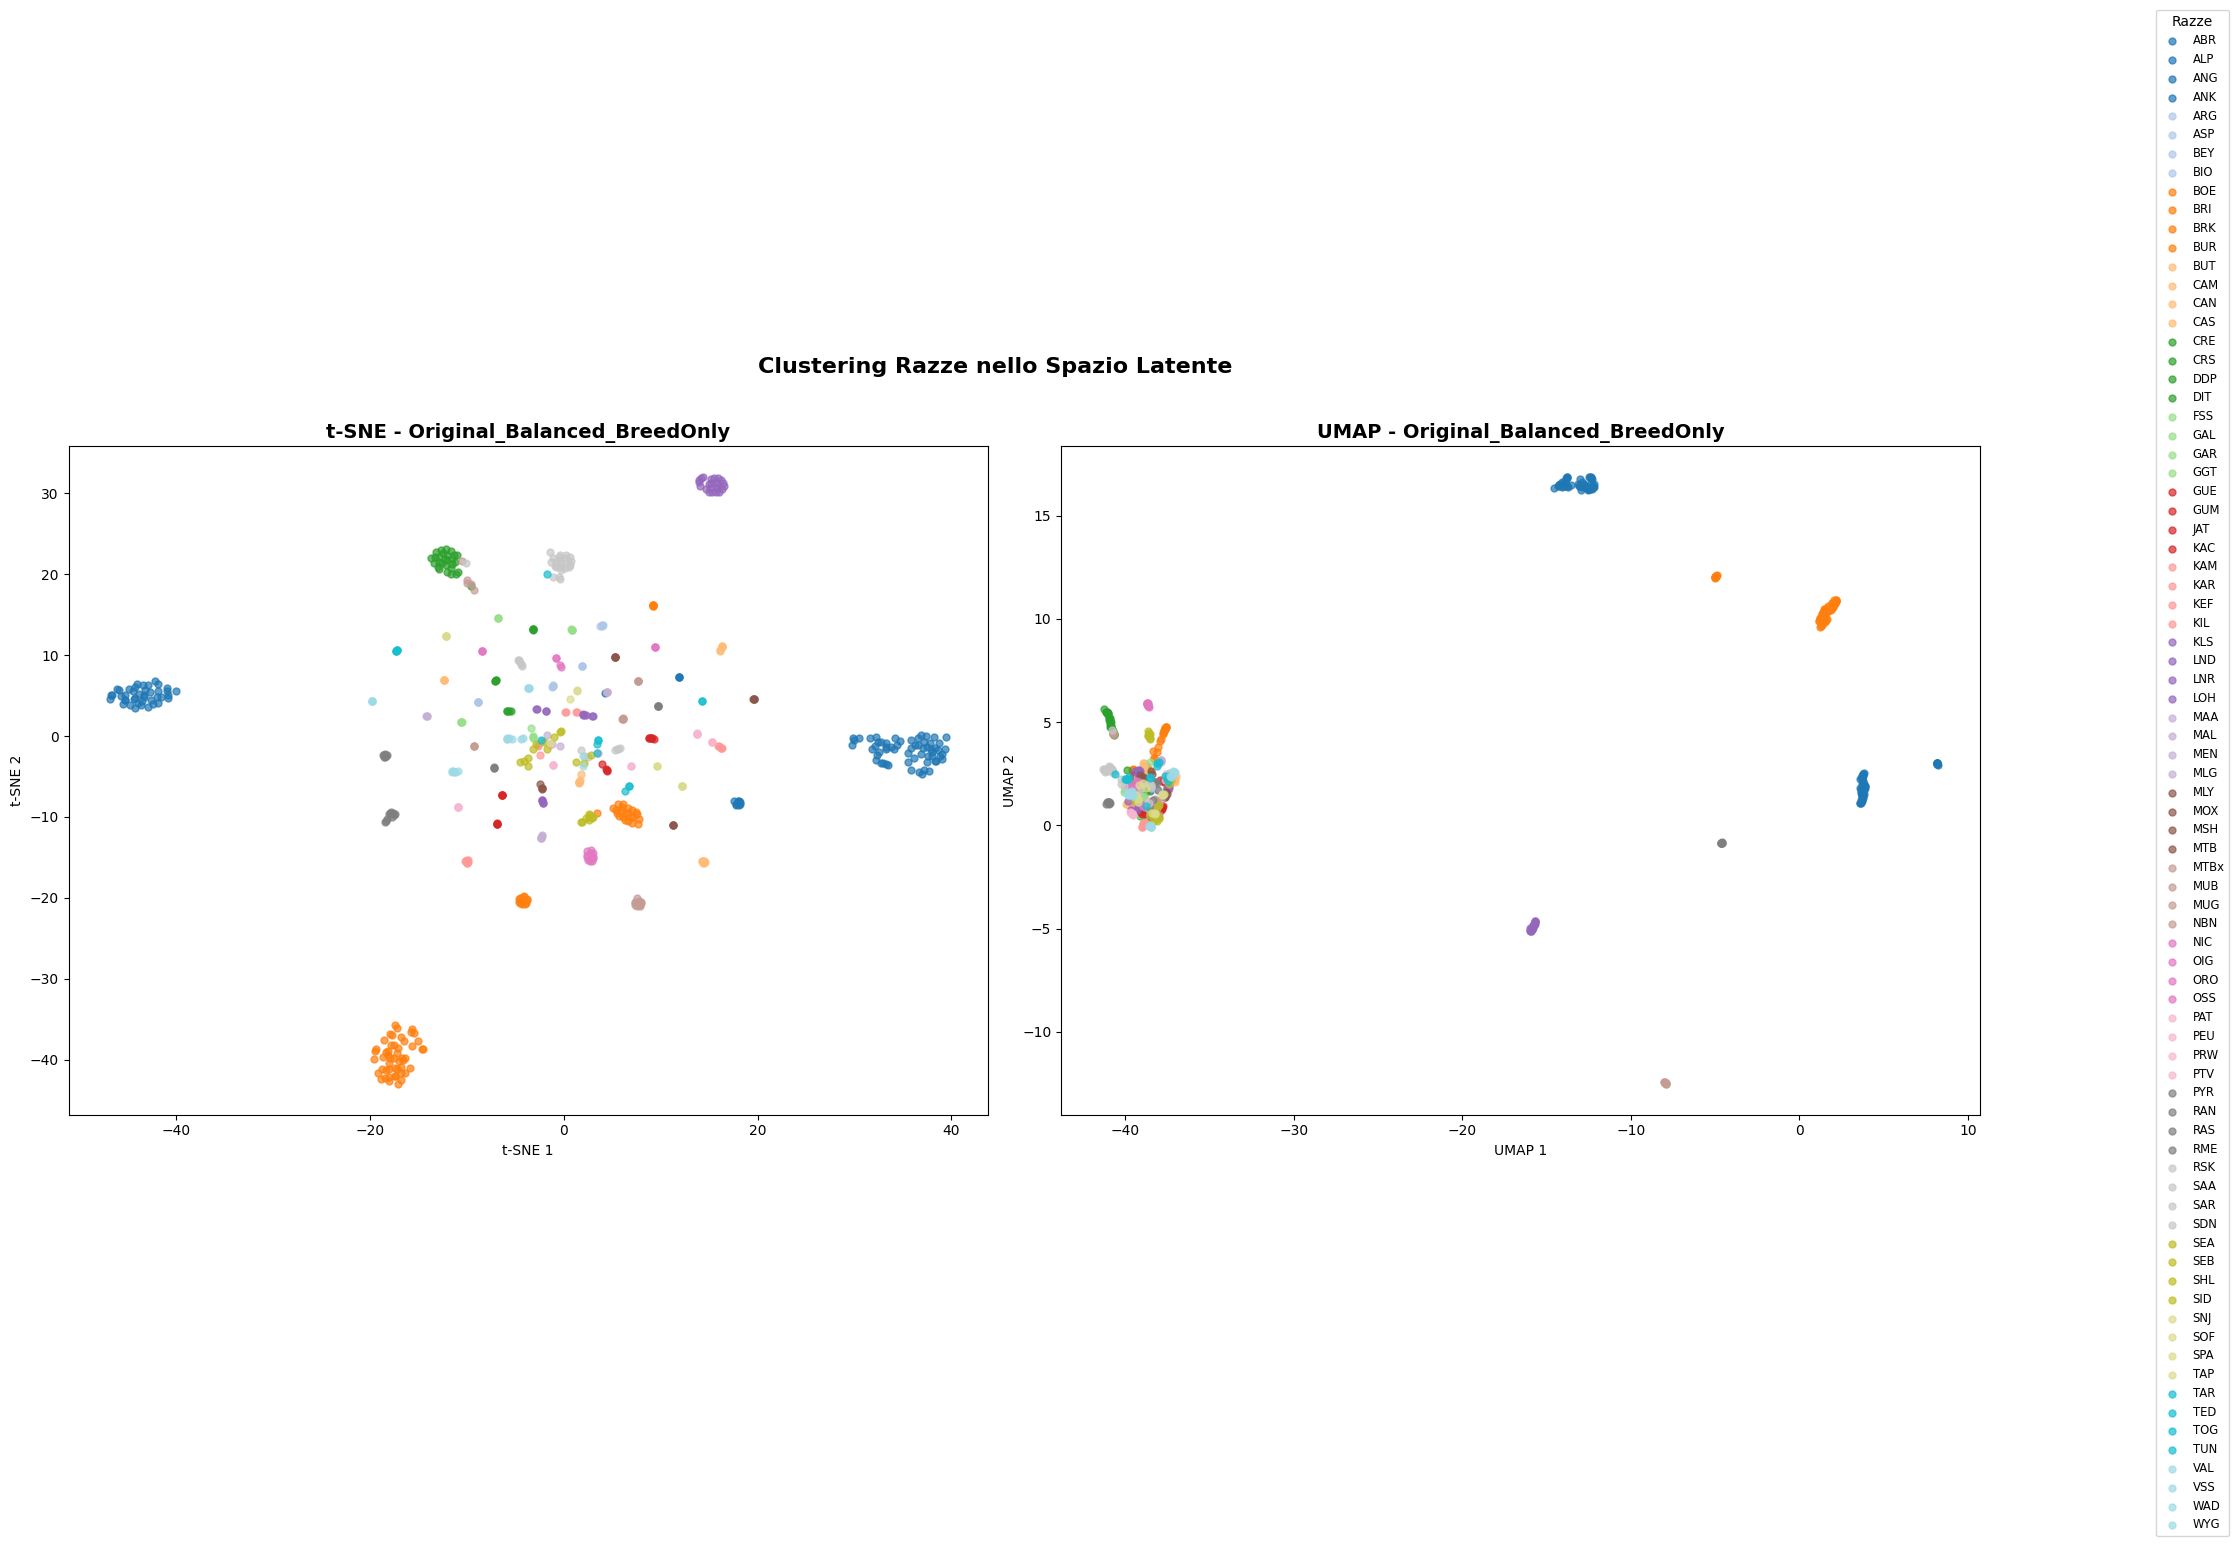


✅ Plot salvato: latent_space_Original_Balanced_BreedOnly_tsne_umap.png


In [8]:
# Visualizzazione Latent Space con t-SNE e UMAP
from sklearn.manifold import TSNE
import umap

if 'model' in dir():
    # Carica dati
    dm = GenomicDataModule(
        bed_path=config['bed_path'],
        batch_size=config['batch_size'],
        maf_thresh=config['maf_thresh'],
        geno_thresh=config['geno_thresh'],
        min_samples_per_class=config['min_samples_per_class'],
        ld_pruning=config['ld_pruning'],
        ld_threshold=config['ld_threshold'],
        ld_window=config['ld_window'],
        metadata_path=config['metadata_path']
    )
    dm.setup()
    
    # Estrai embeddings
    embeddings = []
    labels = []
    
    with torch.no_grad():
        for batch in dm.val_dataloader():
            x = batch[0].to(model.device)
            outputs = model(x)
            embeddings.append(outputs['mu'].cpu().numpy())
            labels.append(batch[1].numpy())
    
    embeddings = np.concatenate(embeddings)
    labels = np.concatenate(labels)
    
    print(f"📊 Embeddings shape: {embeddings.shape}")
    print(f"🏷️ Numero classi: {len(np.unique(labels))}")
    
    # --- t-SNE ---
    print("\n🔄 Calcolo t-SNE...")
    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, n_jobs=-1)
    emb_tsne = tsne.fit_transform(embeddings)
    
    # --- UMAP ---
    print("🔄 Calcolo UMAP...")
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    emb_umap = reducer.fit_transform(embeddings)
    
    # --- Creazione Figure con subplots ---
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    unique_labels = np.unique(labels)
    
    # Colori consistenti tra i due plot
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    color_map = {lbl: colors[i] for i, lbl in enumerate(unique_labels)}
    
    # Plot t-SNE
    for cls_idx in unique_labels:
        mask = labels == cls_idx
        label_name = dm.class_names_breed[cls_idx] if cls_idx < len(dm.class_names_breed) else str(cls_idx)
        axes[0].scatter(emb_tsne[mask, 0], emb_tsne[mask, 1], 
                       c=[color_map[cls_idx]], label=label_name, alpha=0.7, s=25)
    
    axes[0].set_title(f't-SNE - {EXPERIMENT_NAME}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('t-SNE 1')
    axes[0].set_ylabel('t-SNE 2')
    
    # Plot UMAP
    for cls_idx in unique_labels:
        mask = labels == cls_idx
        label_name = dm.class_names_breed[cls_idx] if cls_idx < len(dm.class_names_breed) else str(cls_idx)
        axes[1].scatter(emb_umap[mask, 0], emb_umap[mask, 1], 
                       c=[color_map[cls_idx]], label=label_name, alpha=0.7, s=25)
    
    axes[1].set_title(f'UMAP - {EXPERIMENT_NAME}', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('UMAP 1')
    axes[1].set_ylabel('UMAP 2')
    
    # Legenda unica sulla destra
    handles, lbls = axes[1].get_legend_handles_labels()
    fig.legend(handles, lbls, loc='center right', bbox_to_anchor=(1.12, 0.5), 
               ncol=1, fontsize='small', title='Razze')
    
    plt.suptitle(f'Clustering Razze nello Spazio Latente', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'latent_space_{EXPERIMENT_NAME}_tsne_umap.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ Plot salvato: latent_space_{EXPERIMENT_NAME}_tsne_umap.png")
else:
    print("⚠️ Modello non caricato. Esegui prima la cella di caricamento.")

---

## Note

- I checkpoint dei modelli sono salvati in `checkpoints_vae/<nome_esperimento>/`
- I risultati sono salvati in `experiment_comparison_vae_multitask.csv`
- I plot sono salvati come `plot_vae_<nome_esperimento>_kfold.png`